# Import and Common Functions

In [47]:
# =========================
# Step 0: Import libraries
# =========================

import numpy as np
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(42)

In [50]:
# ==========================================
# Define LIF simulation function
# Noise is added to the input current
# ==========================================

def simulate_lif(
    T=500.0,          # total simulation time (ms)
    dt=0.1,           # time step (ms)
    V_rest=-65.0,     # resting potential (mV)
    V_reset=-65.0,    # reset potential after a spike (mV)
    V_th=-50.0,       # spike threshold (mV)
    R_m=10.0,         # membrane resistance (MΩ)
    tau_m=20.0,       # membrane time constant (ms)
    tau_ref=5.0,      # refractory period (ms)
    I_base=1.8,       # baseline input current
    sigma=0.0         # input current noise intensity
):
    """
    Simulate a single LIF neuron with Gaussian input current noise.

    Returns:
        time        : time axis (ms)
        V           : membrane potential trace (mV)
        spike_times : spike times (ms)
        spike_train : binary spike train (0/1)
    """

    # Number of simulation steps
    n_steps = int(T / dt)

    # Time axis
    time = np.arange(0, T, dt)

    # Membrane potential trace
    V = np.zeros(n_steps)
    V[0] = V_rest

    # Spike outputs
    spike_train = np.zeros(n_steps)
    spike_times = []

    # Refractory period counter
    ref_steps = int(tau_ref / dt)
    ref_count = 0

    for i in range(1, n_steps):
        # If in refractory period, keep neuron at reset potential
        if ref_count > 0:
            V[i] = V_reset
            ref_count -= 1
            continue

        # Deterministic part of the LIF update
        deterministic = ((V_rest - V[i-1]) + R_m * I_base) / tau_m * dt

        # Stochastic part: input current noise
        # This noise enters through the current term
        stochastic = (R_m * sigma / tau_m) * np.sqrt(dt) * np.random.randn()

        # Update membrane potential
        V[i] = V[i-1] + deterministic + stochastic

        # Spike generation
        if V[i] >= V_th:
            V[i] = 20.0  # visible spike peak for plotting
            spike_train[i] = 1
            spike_times.append(time[i])
            ref_count = ref_steps

    return time, V, np.array(spike_times), spike_train

In [51]:
# ==========================================
#  Define helper functions
# ==========================================

def compute_firing_rate(spike_times, T):
    """
    Compute firing rate in Hz.
    """
    return len(spike_times) / (T / 1000.0)


def compute_isi(spike_times):
    """
    Compute inter-spike intervals (ISI) in ms.
    """
    if len(spike_times) < 2:
        return np.array([])
    return np.diff(spike_times)


def compute_cv(isi):
    """
    Compute coefficient of variation (CV) of ISI.
    CV = std(ISI) / mean(ISI)
    """
    if len(isi) < 2 or np.mean(isi) == 0:
        return np.nan
    return np.std(isi) / np.mean(isi)

# Step 1 — Standard LIF vs Moderate-Noise LIF

In [52]:
# ==========================================
#  Step 1 settings and single-trial simulation
# ==========================================

T_step1 = 500.0   # shorter window for visual comparison
dt = 0.1

# Condition A: no input noise
time0, V0, spikes0, train0 = simulate_lif(
    T=T_step1,
    dt=dt,
    sigma=0.0
)

# Condition B: moderate input noise
time1, V1, spikes1, train1 = simulate_lif(
    T=T_step1,
    dt=dt,
    sigma=1.0
)

print("Condition A (sigma = 0.0)")
print("  Number of spikes:", len(spikes0))
print("  Firing rate (Hz):", compute_firing_rate(spikes0, T_step1))

print("\nCondition B (sigma = 1.0)")
print("  Number of spikes:", len(spikes1))
print("  Firing rate (Hz):", compute_firing_rate(spikes1, T_step1))

Condition A (sigma = 0.0)
  Number of spikes: 12
  Firing rate (Hz): 24.0

Condition B (sigma = 1.0)
  Number of spikes: 12
  Firing rate (Hz): 24.0


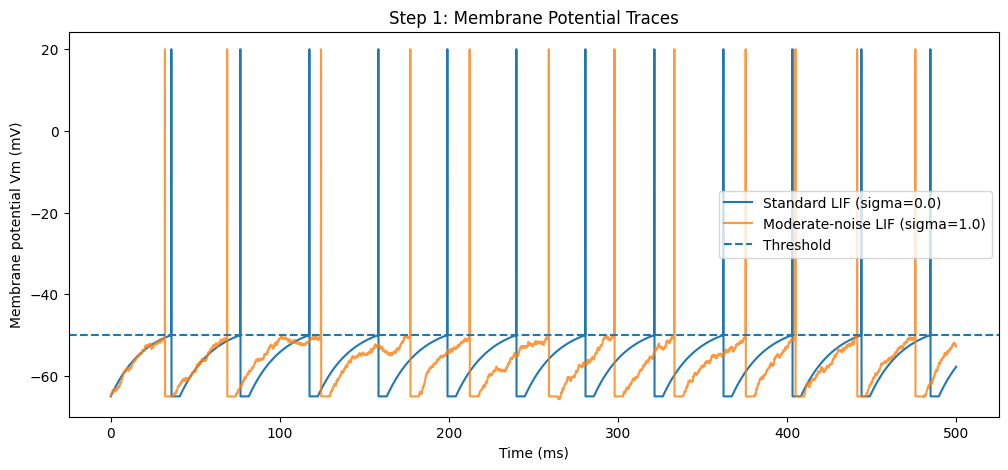

In [53]:
# ==========================================
# Plot membrane potential traces
# ==========================================

plt.figure(figsize=(12, 5))
plt.plot(time0, V0, label='Standard LIF (sigma=0.0)')
plt.plot(time1, V1, label='Moderate-noise LIF (sigma=1.0)', alpha=0.8)
plt.axhline(-50, linestyle='--', label='Threshold')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential Vm (mV)')
plt.title('Step 1: Membrane Potential Traces')
plt.legend()
plt.show()

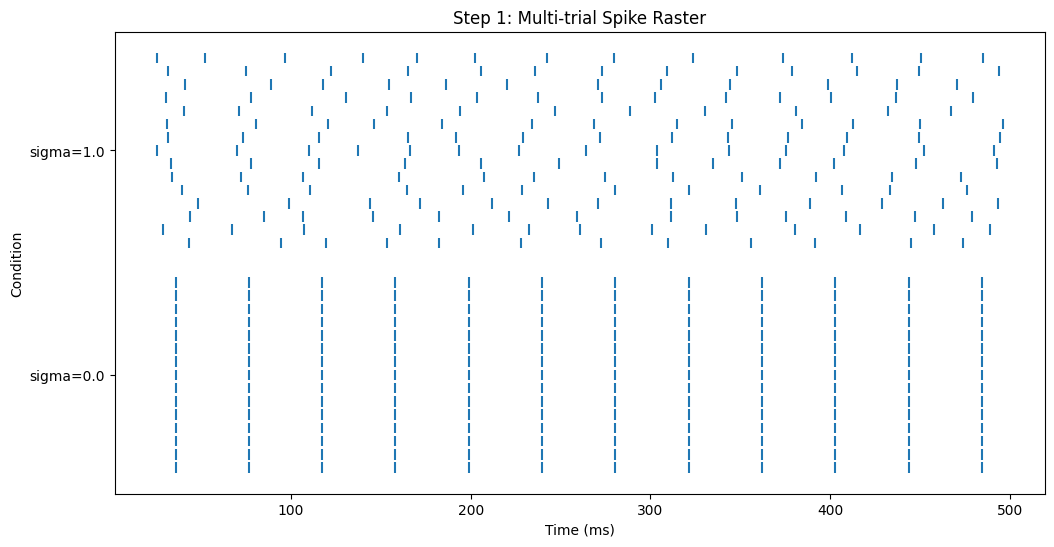

In [54]:
# ==========================================
#  Multi-trial raster plot
# ==========================================

n_trials_raster = 15
sigma_conditions = [0.0, 1.0]
condition_labels = ['sigma=0.0', 'sigma=1.0']

all_spike_times = {0.0: [], 1.0: []}

# Repeat simulations under the same condition
for sigma_value in sigma_conditions:
    for trial in range(n_trials_raster):
        _, _, spike_times, _ = simulate_lif(
            T=T_step1,
            dt=dt,
            sigma=sigma_value
        )
        all_spike_times[sigma_value].append(spike_times)

# Plot raster
plt.figure(figsize=(12, 6))

y_offset = 0
yticks = []
yticklabels = []

for sigma_value, label in zip(sigma_conditions, condition_labels):
    for trial_idx, spike_times in enumerate(all_spike_times[sigma_value]):
        y = np.ones_like(spike_times) * (y_offset + trial_idx + 1)
        plt.vlines(spike_times, y - 0.4, y + 0.4)

    center_y = y_offset + (n_trials_raster + 1) / 2
    yticks.append(center_y)
    yticklabels.append(label)

    y_offset += n_trials_raster + 2

plt.yticks(yticks, yticklabels)
plt.xlabel('Time (ms)')
plt.ylabel('Condition')
plt.title('Step 1: Multi-trial Spike Raster')
plt.show()

# Step 2 — Firing Rate vs Noise Intensity

In [55]:
# ==========================================
# Step 2 settings
# ==========================================

sigma_values = np.arange(0.0, 3.1, 0.3)
T_step2 = 3000.0   # longer simulation for stable firing-rate estimates
n_trials = 20

mean_rates = []
std_rates = []

for sigma_value in sigma_values:
    trial_rates = []

    for trial in range(n_trials):
        _, _, spike_times, _ = simulate_lif(
            T=T_step2,
            dt=dt,
            sigma=sigma_value
        )
        rate = compute_firing_rate(spike_times, T_step2)
        trial_rates.append(rate)

    mean_rates.append(np.mean(trial_rates))
    std_rates.append(np.std(trial_rates))

mean_rates = np.array(mean_rates)
std_rates = np.array(std_rates)

print("Sigma values:")
print(sigma_values)

print("\nMean firing rates (Hz):")
print(mean_rates)

Sigma values:
[0.  0.3 0.6 0.9 1.2 1.5 1.8 2.1 2.4 2.7 3. ]

Mean firing rates (Hz):
[24.33333333 24.4        24.68333333 25.16666667 25.61666667 26.46666667
 26.98333333 28.13333333 28.61666667 29.51666667 29.93333333]


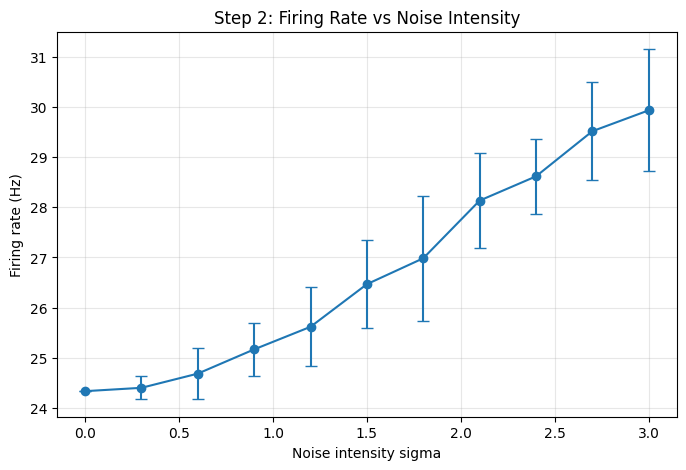

In [56]:
# ==========================================
# Plot firing rate vs sigma
# ==========================================

plt.figure(figsize=(8, 5))
plt.errorbar(sigma_values, mean_rates, yerr=std_rates, marker='o', capsize=4)
plt.xlabel('Noise intensity sigma')
plt.ylabel('Firing rate (Hz)')
plt.title('Step 2: Firing Rate vs Noise Intensity')
plt.grid(True, alpha=0.3)
plt.show()

#  Step 3 — Spike Timing Analysis: ISI and CV

In [57]:
# ==========================================
#  Compute ISI and CV across sigma
# ==========================================

T_step3 = 3000.0   # longer simulation for spike-timing statistics

mean_isi_values = []
std_isi_values = []
mean_cv_values = []
std_cv_values = []

for sigma_value in sigma_values:
    trial_mean_isi = []
    trial_cv = []

    for trial in range(n_trials):
        _, _, spike_times, _ = simulate_lif(
            T=T_step3,
            dt=dt,
            sigma=sigma_value
        )

        isi = compute_isi(spike_times)

        if len(isi) > 0:
            trial_mean_isi.append(np.mean(isi))
            trial_cv.append(compute_cv(isi))

    if len(trial_mean_isi) > 0:
        mean_isi_values.append(np.mean(trial_mean_isi))
        std_isi_values.append(np.std(trial_mean_isi))
    else:
        mean_isi_values.append(np.nan)
        std_isi_values.append(np.nan)

    if len(trial_cv) > 0:
        mean_cv_values.append(np.nanmean(trial_cv))
        std_cv_values.append(np.nanstd(trial_cv))
    else:
        mean_cv_values.append(np.nan)
        std_cv_values.append(np.nan)

mean_isi_values = np.array(mean_isi_values)
std_isi_values = np.array(std_isi_values)
mean_cv_values = np.array(mean_cv_values)
std_cv_values = np.array(std_cv_values)

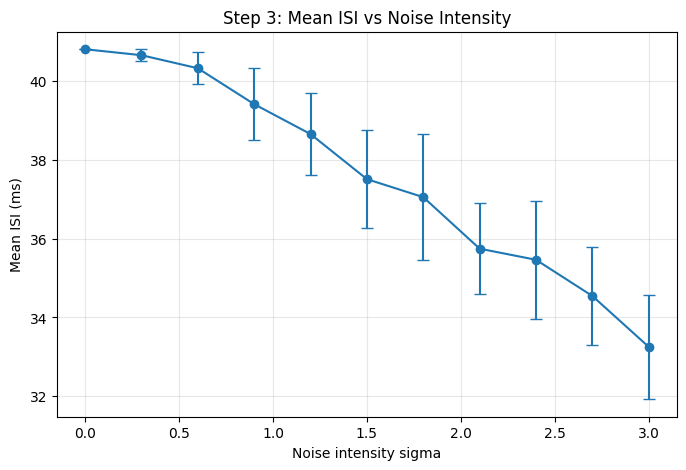

In [58]:
# ==========================================
# Plot mean ISI vs sigma
# ==========================================

plt.figure(figsize=(8, 5))
plt.errorbar(sigma_values, mean_isi_values, yerr=std_isi_values, marker='o', capsize=4)
plt.xlabel('Noise intensity sigma')
plt.ylabel('Mean ISI (ms)')
plt.title('Step 3: Mean ISI vs Noise Intensity')
plt.grid(True, alpha=0.3)
plt.show()

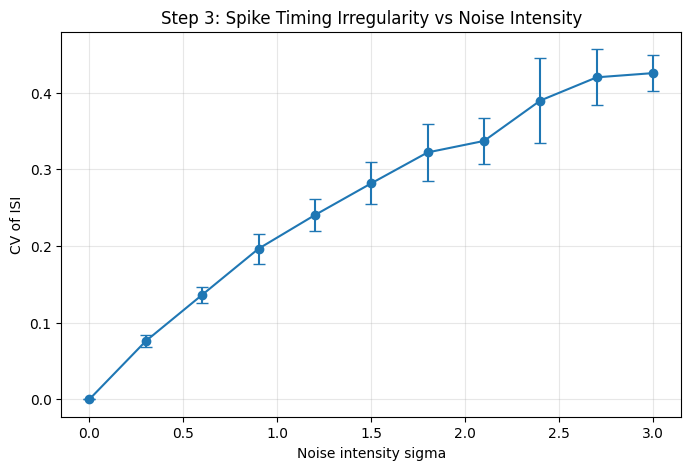

In [59]:
# ==========================================
# Plot CV vs sigma
# ==========================================

plt.figure(figsize=(8, 5))
plt.errorbar(sigma_values, mean_cv_values, yerr=std_cv_values, marker='o', capsize=4)
plt.xlabel('Noise intensity sigma')
plt.ylabel('CV of ISI')
plt.title('Step 3: Spike Timing Irregularity vs Noise Intensity')
plt.grid(True, alpha=0.3)
plt.show()